# dist_pert — Usage Notebook

Basic examples for each perturbation category: **text**, **image**, and **numeric**.

Install the package first if you haven't already:
```bash
pip install -e .           # from the repo root
pip install -e \".[image]\"  # to also enable image perturbers
```

## Text Perturbation
`ContextualWordPerturber` replaces a random fraction of tokens with contextually similar alternatives using a BERT masked-LM.- `aug_p` — fraction of tokens to replace (0.0–1.0)- `aug_min` / `aug_max` — hard floor/ceiling on number of replacements- `model_path` — any HuggingFace masked-LM identifier- `device` — `'cpu'` or `'cuda'`

In [1]:
from dist_pert.text import ContextualWordPerturber

texts = [
    "The storm produced rotating columns of air with wind speeds exceeding 200 mph.",
    "Warmer ocean temperatures increase the intensity of tropical hurricanes.",
]

perturber = ContextualWordPerturber(aug_p=0.2)
results = perturber(texts)

for original, perturbed in zip(texts, results):
    print(f"ORIGINAL : {original}")
    print(f"PERTURBED: {perturbed}")
    print()

/Users/echagnon/vscode-projects/distribution_perturbation/dist_pert_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] The following layers were not sharded: cls.predictions.transform.dense.weight, cls.predictions.transform.dense.bias, bert.encoder.layer.*.attention.self.value.weight, bert.encoder.layer.*.output.LayerNorm.bias, cls.predictions.bias, bert.embeddings.LayerNorm.bias, cls.predictions.transform.LayerNorm.bias, bert.encoder.layer.*.attention.output.dense.bias, bert.encoder.layer.*.attention.output.LayerNorm.bias, cls.predictions.decoder.weight, bert.encoder.layer.*.intermediate.dense.bias, bert.encoder.layer.*.attention.self.value.bias, bert.embeddings.position_embeddings.weight, bert.embeddings.token_type_embeddings.weight, bert.encoder.layer.*.output.dense.bias, bert.encoder

ORIGINAL : The storm produced rotating columns of air with wind speeds exceeding 200 mph.
PERTURBED: The storm produced rotating waves behind air with wind rates exceeding 200 mph.

ORIGINAL : Warmer ocean temperatures increase the intensity of tropical hurricanes.
PERTURBED: Warmer environmental temperatures reduce the intensity to tropical hurricanes.



In [2]:
# aug_min / aug_max give hard bounds on replacements regardless of aug_p
bounded = ContextualWordPerturber(aug_p=0.5, aug_min=1, aug_max=2)
print(bounded(["The quick brown fox jumps over the lazy dog."])[0])

The quick brown fox jumps before my lazy dog.


## Image Perturbation
Two families of image perturbers are available.
### Pixel-level noise
| Class | What it does |
|---|---|
| `GaussianNoisePerturber(sigma)` | Adds `N(0, σ)` to every pixel, clips to valid range |
| `SaltPepperPerturber(amount)` | Randomly sets `amount` fraction of pixels to 0 or 255 |

Both accept `list[np.ndarray]` with shape `(H, W, C)` in either `uint8` or `float32`.

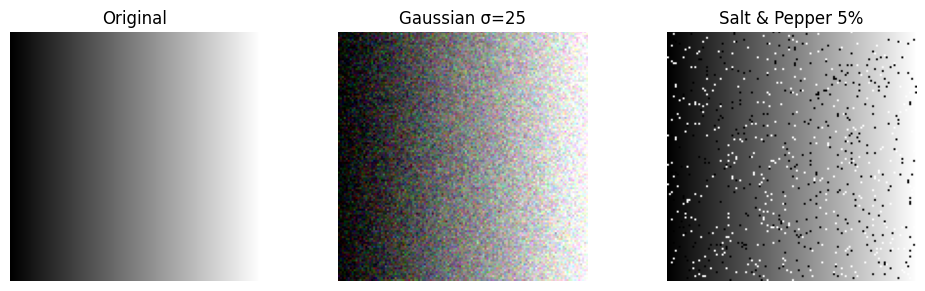

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dist_pert.image import GaussianNoisePerturber, SaltPepperPerturber

# Synthetic gradient image (uint8)
base = np.tile(np.linspace(0, 255, 128, dtype=np.uint8), (128, 1))
image = np.stack([base, base, base], axis=-1)  # shape (128, 128, 3)

gaussian = GaussianNoisePerturber(sigma=25)
saltpepper = SaltPepperPerturber(amount=0.05)

noisy_gaussian = gaussian([image])[0]
noisy_sp = saltpepper([image])[0]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, img, title in zip(
    axes,
    [image, noisy_gaussian, noisy_sp],
    ["Original", "Gaussian σ=25", "Salt & Pepper 5%"],
):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Corruption benchmarks
`ImageCorruptionPerturber` applies ImageNet-C style corruptions at a severity level of 1–5.
Built-in corruptions: `gaussian_blur`, `jpeg_compression`, `shot_noise`, `brightness`, `contrast`.
New corruptions can be registered without subclassing by adding an entry to `CORRUPTION_FNS`:
```python
from dist_pert.image.corruption import CORRUPTION_FNS
CORRUPTION_FNS[\"my_corruption\"] = lambda image, severity: ...
```

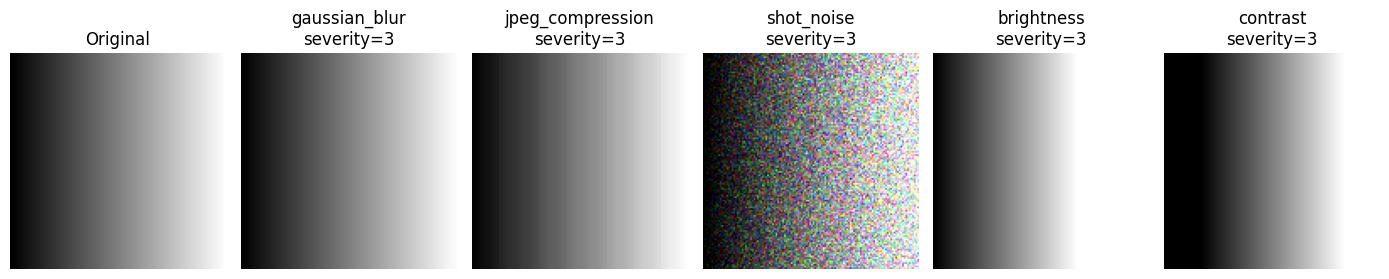

In [4]:
from dist_pert.image import ImageCorruptionPerturber

corruptions = ["gaussian_blur", "jpeg_compression", "shot_noise", "brightness", "contrast"]

fig, axes = plt.subplots(1, len(corruptions) + 1, figsize=(14, 3))
axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, name in zip(axes[1:], corruptions):
    perturber = ImageCorruptionPerturber(corruption=name, severity=3)
    corrupted = perturber([image])[0]
    ax.imshow(corrupted)
    ax.set_title(f"{name}\nseverity=3")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Numeric Perturbation
| Class | Formula |
|---|---|
| `AdditiveGaussianPerturber(sigma)` | `x + N(0, σ)` |
| `MultiplicativeNoisePerturber(scale, distribution)` | `x · factor` where factor ~ lognormal or uniform |

Both accept `list[np.ndarray]` of any shape, or `list[float]`.

In [5]:
from dist_pert.numeric import AdditiveGaussianPerturber, MultiplicativeNoisePerturber

samples = [np.array([1.0, 2.0, 3.0, 4.0, 5.0]) for _ in range(5)]

additive = AdditiveGaussianPerturber(sigma=0.5)
additive_results = additive(samples)

print("Additive Gaussian (σ=0.5)")
for original, perturbed in zip(samples, additive_results):
    print(f"  {np.round(original, 3)}  →  {np.round(perturbed, 3)}")

Additive Gaussian (σ=0.5)
  [1. 2. 3. 4. 5.]  →  [1.536 2.206 2.234 4.43  5.206]
  [1. 2. 3. 4. 5.]  →  [0.616 1.333 2.955 4.432 4.86 ]
  [1. 2. 3. 4. 5.]  →  [0.982 2.457 2.713 4.039 4.454]
  [1. 2. 3. 4. 5.]  →  [0.884 1.018 2.973 4.512 3.876]
  [1. 2. 3. 4. 5.]  →  [1.1   2.256 2.377 3.459 5.331]


In [6]:
multi_ln = MultiplicativeNoisePerturber(scale=0.2, distribution="lognormal")
multi_u = MultiplicativeNoisePerturber(scale=0.2, distribution="uniform")

ln_results = multi_ln(samples)
u_results = multi_u(samples)

print("Multiplicative lognormal (scale=0.2)")
for original, perturbed in zip(samples, ln_results):
    print(f"  {np.round(original, 3)}  →  {np.round(perturbed, 3)}")

print("\nMultiplicative uniform (scale=0.2)")
for original, perturbed in zip(samples, u_results):
    print(f"  {np.round(original, 3)}  →  {np.round(perturbed, 3)}")

Multiplicative lognormal (scale=0.2)
  [1. 2. 3. 4. 5.]  →  [1.039 1.906 3.517 3.603 4.075]
  [1. 2. 3. 4. 5.]  →  [0.939 2.19  2.323 6.025 6.091]
  [1. 2. 3. 4. 5.]  →  [0.931 1.718 2.723 3.33  5.091]
  [1. 2. 3. 4. 5.]  →  [1.216 1.288 2.859 3.594 3.308]
  [1. 2. 3. 4. 5.]  →  [0.851 1.472 2.699 3.714 5.851]

Multiplicative uniform (scale=0.2)
  [1. 2. 3. 4. 5.]  →  [1.071 2.094 2.595 3.345 4.193]
  [1. 2. 3. 4. 5.]  →  [1.154 1.72  2.413 4.326 5.542]
  [1. 2. 3. 4. 5.]  →  [1.033 1.707 3.475 4.217 5.439]
  [1. 2. 3. 4. 5.]  →  [0.867 2.306 2.804 4.653 5.064]
  [1. 2. 3. 4. 5.]  →  [1.01  1.763 2.706 3.685 5.638]


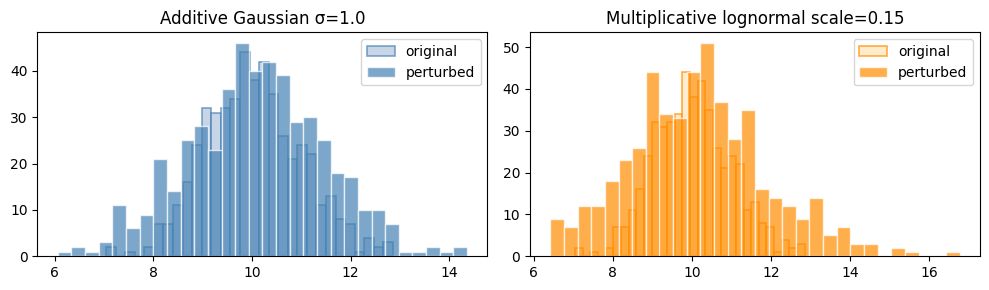

In [7]:
# Visualise how each perturber widens a realistic input distribution
n = 500
original_vals = np.random.normal(loc=10.0, scale=1.0, size=n)

additive_vals = AdditiveGaussianPerturber(sigma=1.0)([original_vals])[0]
multi_vals = MultiplicativeNoisePerturber(scale=0.15)([original_vals])[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].hist(original_vals, bins=30, color="lightsteelblue", edgecolor="steelblue", linewidth=1.2, label="original", alpha=0.7)
axes[0].hist(additive_vals, bins=30, color="steelblue", edgecolor="white", label="perturbed", alpha=0.7)
axes[0].set_title("Additive Gaussian σ=1.0")
axes[0].legend()

axes[1].hist(original_vals, bins=30, color="moccasin", edgecolor="darkorange", linewidth=1.2, label="original", alpha=0.7)
axes[1].hist(multi_vals, bins=30, color="darkorange", edgecolor="white", label="perturbed", alpha=0.7)
axes[1].set_title("Multiplicative lognormal scale=0.15")
axes[1].legend()

plt.tight_layout()
plt.show()